# Segmentasi per gigi (SAM 2) → metrik kerapihan ternormalisasi

Notebook ketiga. Berbeda dari dua sebelumnya, **ini tidak memakai depth sama sekali** — semua
diukur di bidang gambar, tempat proyeksi kamera mengawetkan geometri dengan baik.

```
foto → SAM 2 → mask per gigi → penomoran FDI → landmark → metrik ternormalisasi
```

**Semua metrik dibagi lebar insisivus sentral `w_ref` pada foto yang sama.** Tidak ada milimeter,
tidak ada marker, tidak ada kalibrasi. Gigi menjadi penggarisnya sendiri, dan hasilnya sebanding
antar foto.

Foto di set drg Laura adalah **intraoral retraksi dalam oklusi** — kedua lengkung terlihat. Itu
berarti overbite bisa didekati, sedangkan buccal corridor tidak berlaku (bibir tertahan retraktor).

---

### Koreksi terhadap rencana awal

Sebelumnya kuusulkan **luas tumpang tindih** antar gigi sebagai ukuran berjejal. Setelah dipikir
lagi, itu keliru untuk data segmentasi: kalau gigi B berada di belakang gigi A, SAM hanya
mensegmentasi **bagian B yang terlihat**. Mask-nya terpotong, bukan bertumpang tindih — jadi luas
irisan dua mask praktis selalu nol dan metriknya mati.

Berjejal justru muncul sebagai **kehilangan luas**: gigi yang terdorong ke belakang tampak lebih
sempit dari pasangan cerminnya, dan siluetnya terpotong sehingga kurang cembung. Karena itu
metriknya diganti menjadi `width_asym` dan `solidity` — dua besaran yang mengukur hal yang sama
tapi dengan tanda yang benar.

## 0. Instalasi — **tanpa GitHub Meta**

Repo `facebookresearch/sam2` tidak bisa diakses. Tidak masalah: **SAM 2 sudah didukung langsung
oleh `transformers`**, jadi tidak perlu meng-clone repo mana pun.

```bash
pip install -U "transformers[torch]"
```

Bobot `facebook/sam2.1-hiera-large` (~900 MB) terunduh otomatis dari HuggingFace saat pertama
dipakai — tidak gated, tidak perlu login.

Kedua backend memakai API `pipeline("mask-generation", ...)` yang identik, jadi bedanya cuma
nama model:

| `CFG["backend"]` | Model | Catatan |
|---|---|---|
| `"sam2"` | `facebook/sam2.1-hiera-large` | Batas gigi lebih tajam. Butuh transformers cukup baru |
| `"sam1"` | `facebook/sam-vit-base` | Lebih kasar tapi jalan di transformers versi lama |
| `"auto"` | coba sam2 → mundur ke sam1 | Default |

Kalau SAM 2 gagal dimuat dengan keluhan tipe model tak dikenal, `transformers`-mu terlalu lama —
`pip install -U transformers` biasanya cukup.

**Alternatif ketiga** kalau keduanya rewel: `ultralytics` (sudah kamu punya dari proyek YOLO)
juga membundel SAM 2 lewat `from ultralytics import SAM; SAM("sam2.1_b.pt")`. Ingat lisensinya
AGPL-3.0, sama seperti catatan di proyek YOLO-mu.

Catatan MPS: generasi mask kadang bermasalah di Apple Silicon. Kalau hasilnya kosong atau error,
set `CFG["force_cpu"] = True` — lebih lambat (~1–2 menit/foto) tapi stabil.

In [29]:
# ========= CONFIG =========
CFG = {
    "img_dir":   "Front Teeth drg Laura",
    "out_dir":   "seg_out",
    "backend":   "auto",        # "auto" | "sam2" | "sam1"
    "force_cpu": False,
    "max_side":  1024,          # resize foto sebelum segmentasi

    # --- filter kandidat gigi ---
    "area_min_frac": 0.004,     # luas mask minimum (fraksi luas gambar)
    "area_max_frac": 0.090,
    "sat_max":       0.45,      # gigi = saturasi rendah (gusi/bibir merah -> saturasi tinggi)
    "val_min":       0.42,      # gigi = cukup terang
    "aspect_min":    0.55,      # tinggi/lebar
    "aspect_max":    4.20,      # insisivus lateral bisa sangat ramping -> jangan terlalu ketat
    "solidity_min":  0.78,      # gigi kira-kira cembung
    "nms_iou":       0.45,
    "max_teeth":     14,        # maksimum gigi yang dipertahankan per foto

    # --- landmark ---
    "contact_band": (0.35, 0.90),   # pita vertikal tempat titik kontak dicari (fraksi tinggi gigi)
    "incisal_frac": 0.12,           # fraksi tinggi utk menentukan tepi insisal

    # --- analisis ---
    "n_anterior": 3,            # gigi per sisi yang dianalisis (3 = sentral, lateral, kaninus)
}
print("CFG:", CFG)

CFG: {'img_dir': 'Front Teeth drg Laura', 'out_dir': 'seg_out', 'backend': 'auto', 'force_cpu': False, 'max_side': 1024, 'area_min_frac': 0.004, 'area_max_frac': 0.09, 'sat_max': 0.45, 'val_min': 0.42, 'aspect_min': 0.55, 'aspect_max': 4.2, 'solidity_min': 0.78, 'nms_iou': 0.45, 'max_teeth': 14, 'contact_band': (0.35, 0.9), 'incisal_frac': 0.12, 'n_anterior': 3}


## 1. Setup & pemuatan model

In [30]:
import os, glob, json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly
from PIL import Image
warnings.filterwarnings("ignore")
try:
    from pillow_heif import register_heif_opener; register_heif_opener()
except Exception: pass

import torch
DEV = torch.device("cpu") if CFG["force_cpu"] else torch.device(
    "mps" if torch.backends.mps.is_available() else
    ("cuda" if torch.cuda.is_available() else "cpu"))
print("Device:", DEV)
os.makedirs(CFG["out_dir"], exist_ok=True)

EXTS = ("*.jpg","*.jpeg","*.JPG","*.JPEG","*.png","*.PNG","*.heic","*.HEIC")
paths = sorted(set(sum([glob.glob(os.path.join(CFG["img_dir"], e)) for e in EXTS], [])))
names = [os.path.splitext(os.path.basename(p))[0] for p in paths]
print(f"{len(paths)} foto")

def load_rgb(path, max_side=None):
    max_side = max_side or CFG["max_side"]
    im = Image.open(path).convert("RGB")
    if max(im.size) > max_side:
        sc = max_side/max(im.size)
        im = im.resize((int(im.width*sc), int(im.height*sc)), Image.LANCZOS)
    return np.asarray(im, np.uint8)

Device: mps
18 foto


In [31]:
import transformers
from transformers import pipeline
print("transformers:", transformers.__version__)

# Kedua backend memakai API yang sama -> bedanya cuma nama model. Tidak ada repo GitHub
# yang perlu di-clone; bobot diambil langsung dari HuggingFace Hub.
MODEL_BY_BACKEND = {
    "sam2": "facebook/sam2.1-hiera-large",
    "sam1": "facebook/sam-vit-base",
}
_pipe_dev = 0 if DEV.type == "cuda" else (DEV.type if DEV.type == "mps" else -1)

def _load(backend):
    return pipeline("mask-generation", model=MODEL_BY_BACKEND[backend], device=_pipe_dev)

BACKEND, _gen = None, None
order = ["sam2", "sam1"] if CFG["backend"] == "auto" else [CFG["backend"]]
for b in order:
    try:
        _gen = _load(b); BACKEND = b
        print(f"Backend aktif: {b}  ({MODEL_BY_BACKEND[b]})")
        break
    except Exception as e:
        msg = str(e)[:200]
        print(f"  {b} gagal dimuat: {type(e).__name__}: {msg}")
        if any(k in msg.lower() for k in ("unrecognized", "unknown model", "does not recognize")):
            print("  -> transformers terlalu lama untuk model ini. Jalankan: pip install -U transformers")
if _gen is None:
    raise RuntimeError("Tidak ada backend SAM yang bisa dimuat. Coba `pip install -U \"transformers[torch]\"`.")

def generate_masks(rgb):
    """-> list of bool array (H,W). Seragam untuk semua backend."""
    out = _gen(Image.fromarray(rgb), points_per_batch=64)
    return [np.asarray(m, bool) for m in out["masks"]]

# uji cepat pada satu foto supaya kegagalan ketahuan sekarang, bukan 15 menit lagi
_t = load_rgb(paths[0])
_m = generate_masks(_t)
print(f"Uji: {len(_m)} mask mentah dari '{names[0][:40]}' (ukuran {_t.shape[:2]})")

transformers: 5.14.1


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

Backend aktif: sam2  (facebook/sam2.1-hiera-large)
Uji: 14 mask mentah dari 'kelas 1 dengan diastema 1' (ukuran (696, 1024))


## 2. Menyaring mask yang benar-benar gigi

SAM mensegmentasi **semua** — gusi, bibir, lidah, retraktor, pantulan flash. Foto intraoral
didominasi jaringan merah muda, jadi saringannya cukup tegas:

- **Warna** — gigi bersaturasi rendah & terang; gusi/bibir bersaturasi tinggi
- **Luas** — antara 0.4% dan 9% luas gambar (menyingkirkan mask "seluruh mulut" dan remah kecil)
- **Aspek** — tinggi/lebar antara 0.55 dan 3.2
- **Soliditas** — gigi kira-kira cembung; mask gusi berlekuk-lekuk
- **NMS** — SAM sering mengeluarkan beberapa versi objek yang sama; sisakan satu

Nilai ambangnya ada di CFG dan memang perlu disetel sambil melihat hasilnya.

In [32]:
def rgb_to_sv(rgb01):
    mx = rgb01.max(-1); mn = rgb01.min(-1)
    s = np.where(mx > 1e-6, (mx-mn)/(mx+1e-6), 0.0)
    return s, mx

def convex_area(mask):
    """Luas convex hull mask (tanpa cv2): hull dari titik tepi via monotone chain."""
    ys, xs = np.nonzero(mask)
    if len(xs) < 3: return float(mask.sum())
    pts = sorted(set(zip(xs.tolist(), ys.tolist())))
    if len(pts) < 3: return float(mask.sum())
    def cross(o,a,b): return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
    lower=[]
    for p in pts:
        while len(lower)>=2 and cross(lower[-2],lower[-1],p) <= 0: lower.pop()
        lower.append(p)
    upper=[]
    for p in reversed(pts):
        while len(upper)>=2 and cross(upper[-2],upper[-1],p) <= 0: upper.pop()
        upper.append(p)
    hull = lower[:-1]+upper[:-1]
    if len(hull) < 3: return float(mask.sum())
    a = 0.0
    for i in range(len(hull)):
        x1,y1 = hull[i]; x2,y2 = hull[(i+1) % len(hull)]
        a += x1*y2 - x2*y1
    return abs(a)/2 + 1e-6

def mask_stats(mask, rgb01, s, v):
    ys, xs = np.nonzero(mask)
    if len(xs) < 20: return None
    area = float(mask.sum())
    x0,x1,y0,y1 = xs.min(), xs.max(), ys.min(), ys.max()
    bw, bh = (x1-x0+1), (y1-y0+1)
    return {
        "area": area, "frac": area/mask.size,
        "cx": float(xs.mean()), "cy": float(ys.mean()),
        "x0":int(x0), "x1":int(x1), "y0":int(y0), "y1":int(y1),
        "aspect": bh/max(bw,1),
        "sat": float(s[mask].mean()), "val": float(v[mask].mean()),
        "solidity": area/convex_area(mask),
    }

def iou(a, b):
    inter = np.logical_and(a,b).sum()
    if inter == 0: return 0.0
    return float(inter/np.logical_or(a,b).sum())

def filter_teeth(masks, rgb):
    rgb01 = rgb.astype(np.float32)/255.
    s, v = rgb_to_sv(rgb01)
    cand = []
    for m in masks:
        st = mask_stats(m, rgb01, s, v)
        if st is None: continue
        if not (CFG["area_min_frac"] <= st["frac"] <= CFG["area_max_frac"]): continue
        if st["sat"] > CFG["sat_max"] or st["val"] < CFG["val_min"]:        continue
        if not (CFG["aspect_min"] <= st["aspect"] <= CFG["aspect_max"]):    continue
        if st["solidity"] < CFG["solidity_min"]:                            continue
        st["score"] = st["val"]*(1-st["sat"])*st["solidity"]
        cand.append((m, st))
    cand.sort(key=lambda t: -t[1]["score"])
    keep = []
    for m, st in cand:
        if all(iou(m, k[0]) < CFG["nms_iou"] for k in keep):
            keep.append((m, st))
        if len(keep) >= CFG["max_teeth"]: break
    return keep

## 3. Pisah lengkung atas/bawah & penomoran FDI

Pemisahan atas/bawah memakai **1-D k-means (k=2) pada koordinat-y sentroid**. Pada foto oklusi
retraksi, kedua lengkung membentuk dua kelompok yang terpisah rapi di sumbu vertikal.

Penomoran mengikuti konvensi: **kiri gambar = sisi kanan pasien**.

| | kiri gambar → kanan gambar |
|---|---|
| Atas | 13, 12, 11 \| 21, 22, 23 |
| Bawah | 43, 42, 41 \| 31, 32, 33 |

Midline lengkung diambil dari **median sentroid-x** semua gigi pada lengkung itu, lalu penomoran
berjalan keluar dari midline ke dua arah. Semua bisa ditimpa manual di sel `OVERRIDE`.

> **Jebakan yang harus kamu tahu.** Penomoran ini berbasis **urutan posisi**, bukan pengenalan
> gigi. Kalau satu gigi gagal tersegmentasi, semua nomor sesudahnya **bergeser diam-diam** —
> kaninus bisa terbaca sebagai lateral, dan metriknya tetap keluar tanpa error. Ini kegagalan
> senyap, jenis yang paling berbahaya.
>
> Karena itu ada kolom `fdi_suspect` di tabel metrik, dengan dua pemeriksaan murah: jumlah gigi
> anterior atas harus 6, dan insisivus sentral harus termasuk dua gigi terlebar. Foto yang
> ditandai **harus** diperbaiki lewat `OVERRIDE` sebelum metriknya dipakai.

In [33]:
def split_arches(items):
    """1-D k-means (k=2) pada cy -> (idx_atas, idx_bawah)."""
    cy = np.array([st["cy"] for _, st in items], float)
    if len(cy) < 2: return list(range(len(cy))), []
    c = np.array([cy.min(), cy.max()], float)
    for _ in range(50):
        lab = (np.abs(cy[:,None]-c[None,:])).argmin(1)
        for k in (0,1):
            if (lab==k).any(): c[k] = cy[lab==k].mean()
    upper = [i for i in range(len(cy)) if lab[i]==0]
    lower = [i for i in range(len(cy)) if lab[i]==1]
    if c[0] > c[1]: upper, lower = lower, upper       # atas = cy lebih kecil
    return upper, lower

def assign_fdi(items, idxs, arch):
    """arch='upper' -> 1x/2x ; 'lower' -> 4x/3x. Kiri gambar = kanan pasien."""
    if not idxs: return {}
    cxs = np.array([items[i][1]["cx"] for i in idxs], float)
    mid = float(np.median(cxs))
    left  = sorted([i for i in idxs if items[i][1]["cx"] <  mid],
                   key=lambda i: -items[i][1]["cx"])     # dari midline ke luar
    right = sorted([i for i in idxs if items[i][1]["cx"] >= mid],
                   key=lambda i:  items[i][1]["cx"])
    qL, qR = (1, 2) if arch == "upper" else (4, 3)
    out = {}
    for r, i in enumerate(left):  out[i] = qL*10 + (r+1) if r < 8 else None
    for r, i in enumerate(right): out[i] = qR*10 + (r+1) if r < 8 else None
    return {k: v for k, v in out.items() if v}

def segment_photo(path):
    rgb = load_rgb(path)
    keep = filter_teeth(generate_masks(rgb), rgb)
    up, lo = split_arches(keep)
    fdi = {}; fdi.update(assign_fdi(keep, up, "upper")); fdi.update(assign_fdi(keep, lo, "lower"))
    return rgb, keep, fdi

In [34]:
# Segmentasi seluruh dataset (bagian paling lambat: ~10-60 dtk/foto)
import time
SEG = {}
t0 = time.time()
for p, n in zip(paths, names):
    try:
        rgb, keep, fdi = segment_photo(p)
        SEG[n] = {"rgb": rgb, "keep": keep, "fdi": fdi}
        ups = sum(1 for v in fdi.values() if v//10 in (1,2))
        print(f"  {n[:44]:44s} {len(keep):2d} mask | atas {ups:2d} | bawah {len(fdi)-ups:2d}")
    except Exception as e:
        print(f"  {n[:44]:44s} GAGAL: {type(e).__name__} {str(e)[:80]}")
print(f"\n{len(SEG)} foto tersegmentasi dalam {time.time()-t0:.0f}s")
np.save(os.path.join(CFG["out_dir"], "fdi_map.npy"),
        {n: SEG[n]["fdi"] for n in SEG}, allow_pickle=True)

  kelas 1 dengan diastema 1                     6 mask | atas  1 | bawah  5
  kelas 1 dengan diastema 2                     8 mask | atas  5 | bawah  3
  kelas 1 normal 1                             12 mask | atas  8 | bawah  4
  kelas 1 normal 2                             14 mask | atas  1 | bawah 13
  kelas 1 normal 3                             11 mask | atas  8 | bawah  3
  kelas 1 with crossbite and crowding 1        14 mask | atas  1 | bawah 13
  kelas 1 with crowding lower anterior 1       13 mask | atas  7 | bawah  6
  kelas 1 with crowding lower anterior 2       14 mask | atas  8 | bawah  6
  kelas 1 with crowding, midline shifting, cro 14 mask | atas 13 | bawah  1
  kelas 1 with crowding, midline shifting, cro  7 mask | atas  1 | bawah  6
  kelas 1 with deep bite and protrusion 1       6 mask | atas  2 | bawah  4
  kelas 1 with deep bite and protrusion 2       0 mask | atas  0 | bawah  0
  kelas 1 with deep bite and protrusion 3       9 mask | atas  5 | bawah  4
  kelas 1 wi

## 4. Tinjau hasil — ini langkah wajib, bukan opsional

Segmentasi otomatis **akan** salah pada sebagian foto. Periksa tiga hal di setiap panel:

1. Apakah setiap poligon benar-benar satu gigi (bukan dua gigi menyatu, bukan gusi)?
2. Apakah pembagian atas/bawah benar (warna berbeda)?
3. Apakah nomor FDI-nya masuk akal — khususnya **11 dan 21 harus mengapit midline**?

Yang salah dicatat di sel `OVERRIDE` setelahnya.

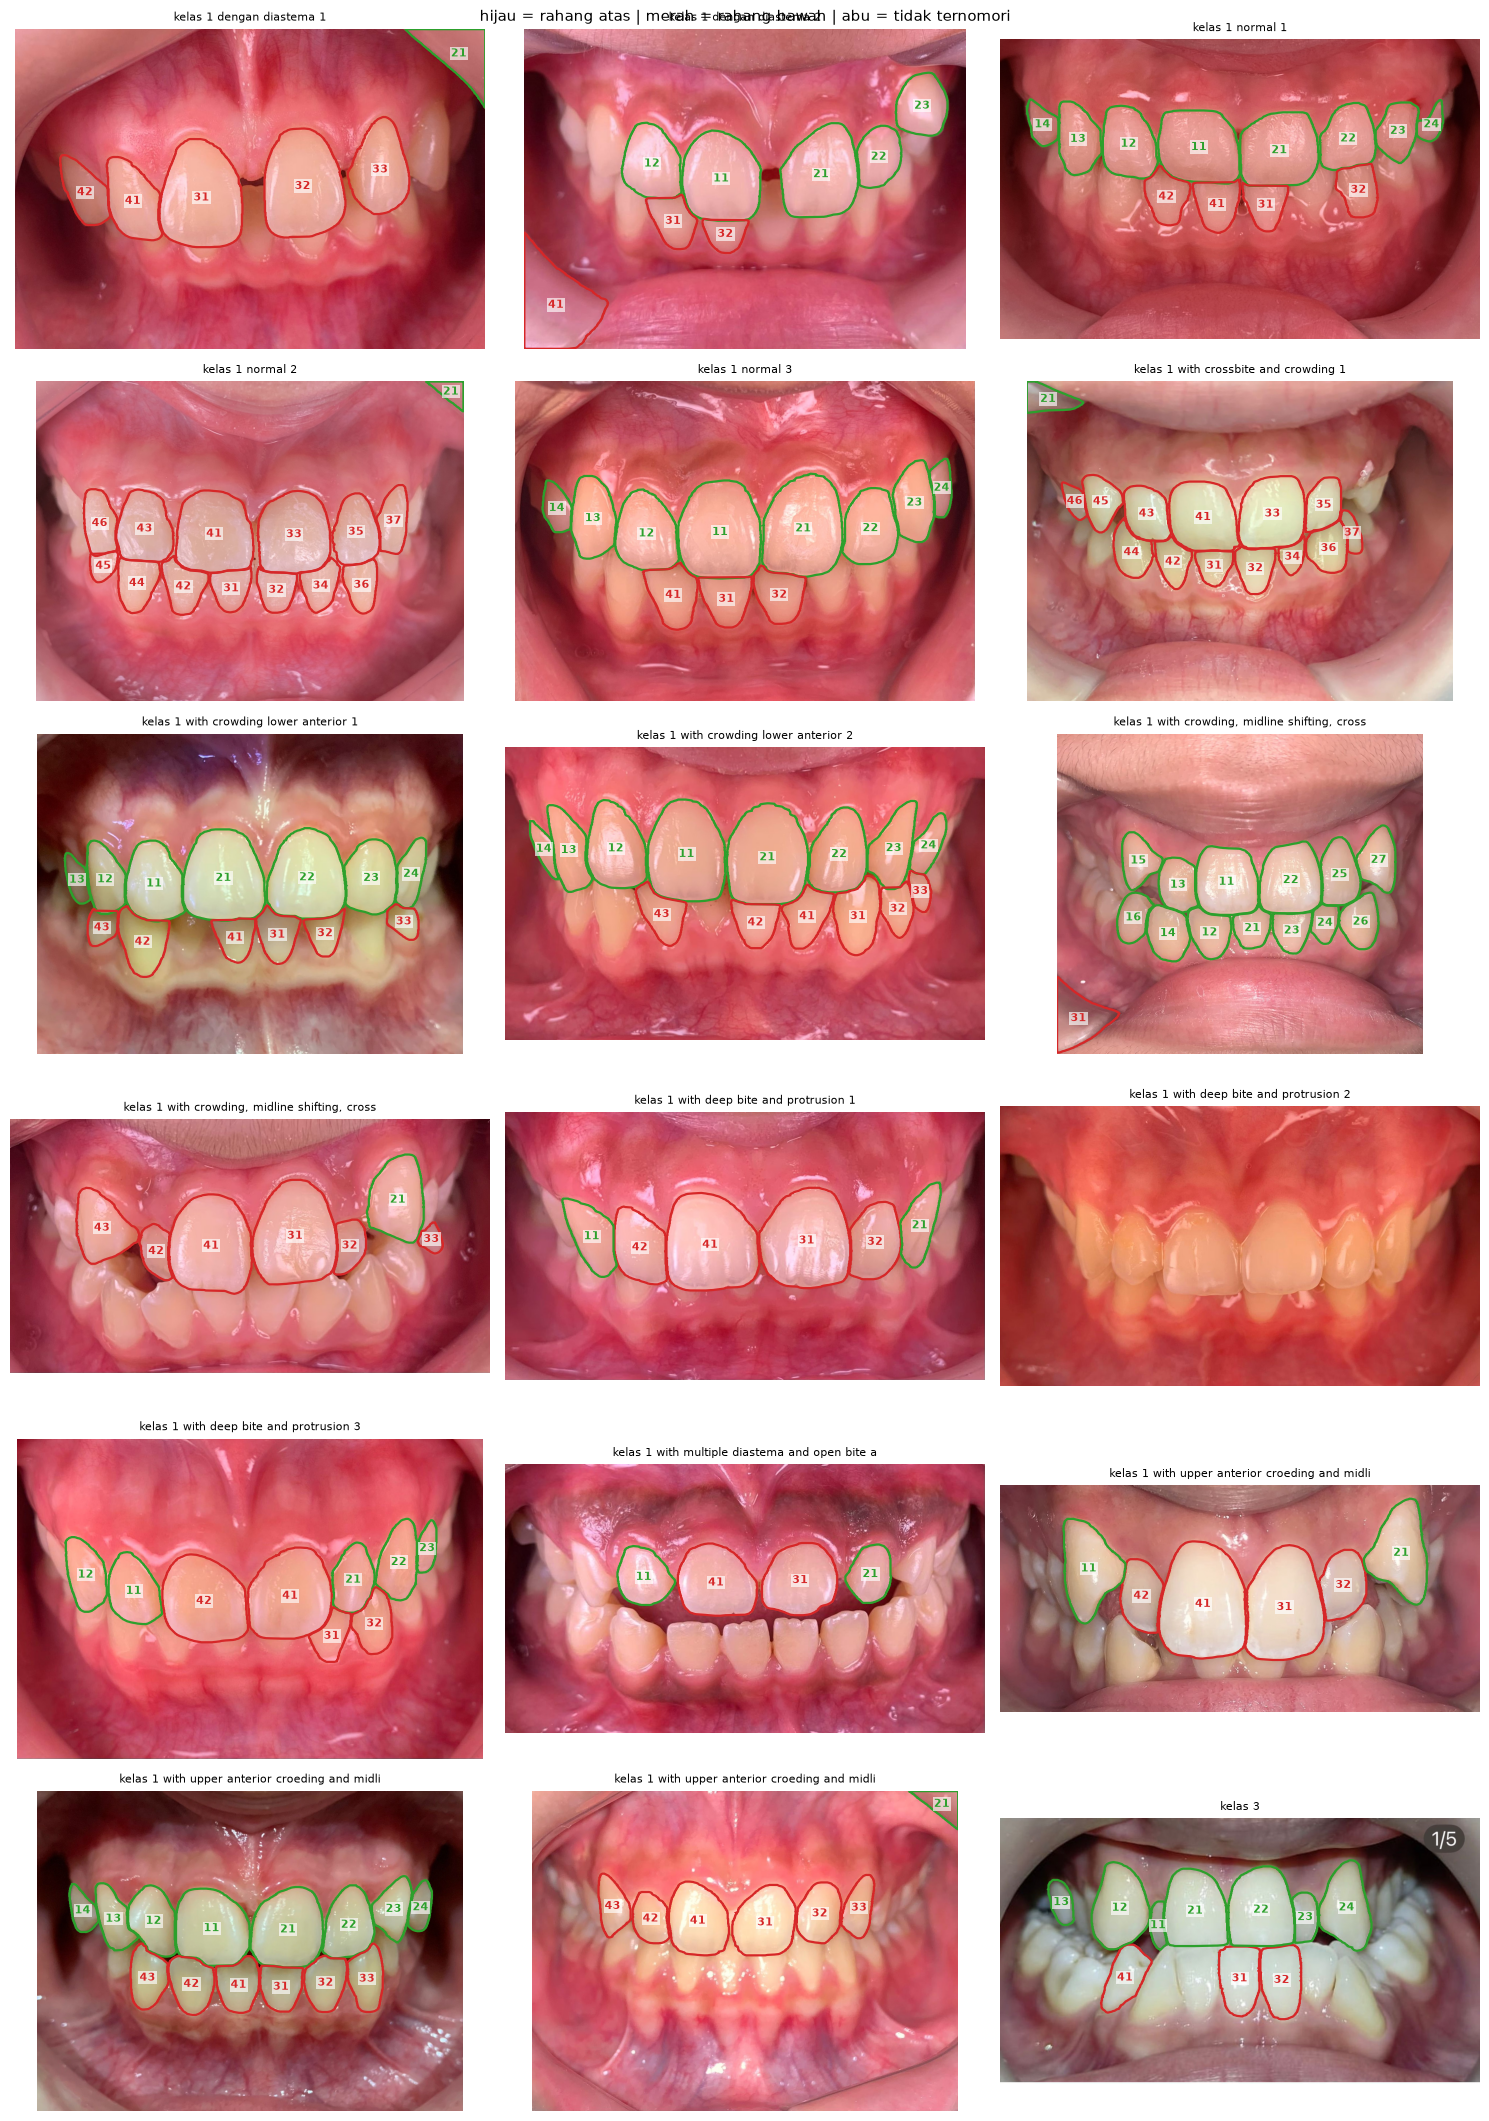

In [35]:
def mask_outline(mask):
    """Kontur kasar tanpa cv2: untuk tiap baris ambil x-min & x-max, rangkai jadi poligon."""
    ys = np.unique(np.nonzero(mask)[0])
    if len(ys) < 2: return None
    left, right = [], []
    for y in ys:
        xs = np.nonzero(mask[y])[0]
        left.append((xs.min(), y)); right.append((xs.max(), y))
    return np.array(left + right[::-1], float)

def show_photo(n, ax=None):
    d = SEG[n]; rgb, keep, fdi = d["rgb"], d["keep"], d["fdi"]
    if ax is None: _, ax = plt.subplots(figsize=(7,5))
    ax.imshow(rgb); ax.axis("off"); ax.set_title(n[:46], fontsize=8)
    for i, (m, st) in enumerate(keep):
        num = fdi.get(i)
        col = "#2ca02c" if (num and num//10 in (1,2)) else ("#d62728" if num else "#999999")
        out = mask_outline(m)
        if out is not None:
            ax.add_patch(MplPoly(out, closed=True, fill=False, edgecolor=col, lw=1.6))
        ax.text(st["cx"], st["cy"], str(num or "?"), color=col, fontsize=8,
                ha="center", va="center", weight="bold",
                bbox=dict(fc="white", ec="none", alpha=0.65, pad=0.8))

ns = list(SEG)
ncol = 3; nrow = int(np.ceil(len(ns)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.6*nrow))
for a in np.ravel(axes): a.axis("off")
for k, n in enumerate(ns): show_photo(n, np.ravel(axes)[k])
plt.suptitle("hijau = rahang atas | merah = rahang bawah | abu = tidak ternomori", fontsize=11)
plt.tight_layout(); plt.show()

In [36]:
# ========= OVERRIDE MANUAL =========
# Isi setelah melihat panel di atas. Format:
#   "nama file (tanpa ekstensi)": {"drop": [idx,...], "fdi": {idx: nomor_fdi, ...}}
# idx = angka yang tercetak di panel (yang "?" pun punya idx; lihat urutannya di sel berikut).
OVERRIDE = {
    # "kelas 1 normal 3": {"drop": [7], "fdi": {2: 11, 3: 21}},
}

def idx_table(n):
    d = SEG[n]
    rows = [{"idx": i, "fdi": d["fdi"].get(i), "cx": round(st["cx"]), "cy": round(st["cy"]),
             "area%": round(100*st["frac"], 2)} for i,(m,st) in enumerate(d["keep"])]
    return pd.DataFrame(rows).sort_values("cx")

for n, ov in OVERRIDE.items():
    if n not in SEG: print("tidak ada:", n); continue
    d = SEG[n]
    for i in ov.get("drop", []): d["fdi"].pop(i, None)
    d["fdi"].update({int(k): int(v) for k, v in ov.get("fdi", {}).items()})
print("Override diterapkan:", list(OVERRIDE) or "(belum ada)")
print("\nContoh tabel indeks (ganti namanya sesuai kebutuhan):")
print(idx_table(ns[0]).to_string(index=False))

Override diterapkan: (belum ada)

Contoh tabel indeks (ganti namanya sesuai kebutuhan):
 idx  fdi  cx  cy  area%
   4   42 153 355   1.45
   2   41 257 374   2.24
   0   31 406 366   4.84
   1   32 626 341   4.80
   3   33 795 305   2.81
   5   21 966  53   1.94


## 5. Landmark per gigi

Tiap mask diringkas menjadi:

- **Sentroid** dan **PCA** → sumbu panjang (`tilt`, derajat dari vertikal), lebar `w`, tinggi `h`
- **Titik kontak** mesial & distal — titik terjauh kiri/kanan di dalam pita vertikal `contact_band`
  (sepertiga tengah-insisal, tempat gigi bertetangga sesungguhnya bersentuhan)
- **Titik insisal** — median-x dari `incisal_frac` baris terbawah (atas) atau teratas (bawah)
- **Soliditas** — luas ÷ luas convex hull; turun bila siluetnya terpotong gigi tetangga

`tilt` diukur dari **vertikal**, bukan horizontal, supaya angkanya langsung terbaca: 0° = tegak.

In [37]:
def landmarks(mask, arch):
    ys, xs = np.nonzero(mask)
    pts = np.stack([xs, ys], 1).astype(float)
    c = pts.mean(0)
    X = pts - c
    evals, evecs = np.linalg.eigh(X.T @ X / len(X))
    o = np.argsort(evals)[::-1]
    major, minor = evecs[:, o[0]], evecs[:, o[1]]
    h = float(np.ptp(X @ major)); w = float(np.ptp(X @ minor))
    if h < w:                                  # pastikan 'major' = sumbu panjang gigi (vertikal)
        major, minor = minor, major; h, w = w, h
    ang = np.degrees(np.arctan2(major[0], major[1]))   # 0 = tegak
    if ang >  90: ang -= 180
    if ang <= -90: ang += 180

    y0, y1 = ys.min(), ys.max()
    H = max(y1 - y0, 1)
    lo, hi = CFG["contact_band"]
    band = (ys >= y0 + lo*H) & (ys <= y0 + hi*H)
    if band.sum() < 10: band = np.ones_like(ys, bool)
    bxs, bys = xs[band], ys[band]
    iL, iR = int(np.argmin(bxs)), int(np.argmax(bxs))
    contact_L = np.array([bxs[iL], bys[iL]], float)
    contact_R = np.array([bxs[iR], bys[iR]], float)

    f = CFG["incisal_frac"]
    if arch == "upper": sel = ys >= y1 - f*H
    else:               sel = ys <= y0 + f*H
    if sel.sum() < 5: sel = np.ones_like(ys, bool)
    incisal = np.array([np.median(xs[sel]), np.median(ys[sel])], float)

    return {"cx": c[0], "cy": c[1], "w": w, "h": h, "tilt": float(ang),
            "contact_L": contact_L, "contact_R": contact_R, "incisal": incisal,
            "area": float(mask.sum()),
            "solidity": float(mask.sum()/convex_area(mask)),
            "y0": float(y0), "y1": float(y1)}

def photo_landmarks(n):
    d = SEG[n]
    out = {}
    for i, (m, st) in enumerate(d["keep"]):
        num = d["fdi"].get(i)
        if not num: continue
        out[num] = landmarks(m, "upper" if num//10 in (1,2) else "lower")
    return out

LM = {n: photo_landmarks(n) for n in SEG}
print("gigi ternomori per foto:")
for n in LM: print(f"  {n[:44]:44s} {sorted(LM[n])}")

gigi ternomori per foto:
  kelas 1 dengan diastema 1                    [21, 31, 32, 33, 41, 42]
  kelas 1 dengan diastema 2                    [11, 12, 21, 22, 23, 31, 32, 41]
  kelas 1 normal 1                             [11, 12, 13, 14, 21, 22, 23, 24, 31, 32, 41, 42]
  kelas 1 normal 2                             [21, 31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46]
  kelas 1 normal 3                             [11, 12, 13, 14, 21, 22, 23, 24, 31, 32, 41]
  kelas 1 with crossbite and crowding 1        [21, 31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46]
  kelas 1 with crowding lower anterior 1       [11, 12, 13, 21, 22, 23, 24, 31, 32, 33, 41, 42, 43]
  kelas 1 with crowding lower anterior 2       [11, 12, 13, 14, 21, 22, 23, 24, 31, 32, 33, 41, 42, 43]
  kelas 1 with crowding, midline shifting, cro [11, 12, 13, 14, 15, 16, 21, 22, 23, 24, 25, 26, 27, 31]
  kelas 1 with crowding, midline shifting, cro [21, 31, 32, 33, 41, 42, 43]
  kelas 1 with deep bite and protrusion 1  

## 6. Metrik kerapihan

Semua berikut **tanpa satuan**, dibagi `w_ref` = lebar rata-rata insisivus sentral (11 & 21).

| Metrik | Definisi | Naik berarti |
|---|---|---|
| `LII_norm` | Σ jarak titik kontak bertetangga ÷ `w_ref` | Makin berjejal / tidak sejajar |
| `incisal_rms` | RMS residu tepi insisal terhadap kurva kuadratik ÷ `w_ref` | Tepi insisal makin tidak beraturan |
| `tilt_std` | simpangan baku sudut aksial (°) | Rotasi/kemiringan makin bervariasi |
| `tilt_asym` | rata-rata \|tilt + tilt_cermin\| (°) | Kemiringan kiri-kanan tidak simetris |
| `width_asym` | rata-rata \|w − w_cermin\| ÷ `w_ref` | Gigi terdorong ke belakang → tampak sempit |
| `solidity_min` | soliditas terendah antar gigi | (turun) siluet terpotong tetangga |
| `midline_dev` | \|x kontak sentral − midline\| ÷ `w_ref` | Midline bergeser |
| `cant_deg` | kemiringan garis fit tepi insisal (°) | Bidang insisal miring |
| `wh_central` | w ÷ h insisivus sentral | Proporsi (rujukan estetik ~0.75–0.85) |
| `overbite_proxy` | 1 − tinggi tampak insisivus bawah ÷ tinggi tampak kaninus bawah | Deep bite; negatif → open bite |

**Catatan kejujuran untuk `overbite_proxy`:** ini pendekatan, bukan overbite sejati. Ia berasumsi
kaninus bawah relatif tidak tertutup — asumsi yang runtuh pada deep bite berat. Perlakukan sebagai
peringkat, bukan pengukuran, dan tanyakan ke drg. Laura apakah urutannya masuk akal.

In [38]:
UPPER_ANT = [13,12,11,21,22,23]
LOWER_ANT = [43,42,41,31,32,33]
MIRROR = {11:21, 12:22, 13:23, 21:11, 22:12, 23:13,
          41:31, 42:32, 43:33, 31:41, 32:42, 33:43}

def _fit_resid(P):
    """RMS residu titik (x,y) terhadap fit kuadratik y=f(x)."""
    if len(P) < 4: return np.nan
    x, y = P[:,0], P[:,1]
    xs = (x - x.mean())/(np.ptp(x) + 1e-8)
    cf = np.polyfit(xs, y, 2)
    return float(np.sqrt(np.mean((y - np.polyval(cf, xs))**2)))

def metrics(lm):
    M = {}
    present = [t for t in UPPER_ANT if t in lm]
    if 11 not in lm or 21 not in lm or len(present) < 4:
        return {"n_upper": len(present), "valid": False}
    w_ref = 0.5*(lm[11]["w"] + lm[21]["w"])
    M["w_ref_px"] = w_ref; M["n_upper"] = len(present); M["valid"] = True

    # --- PERINGATAN penomoran ---
    # assign_fdi menomori berdasarkan URUTAN dari midline. Kalau ada satu gigi yang gagal
    # tersegmentasi, semua nomor sesudahnya bergeser diam-diam (kaninus bisa terbaca sbg lateral).
    # Dua pemeriksaan murah: (1) gigi anterior atas harus 6; (2) insisivus sentral harus termasuk
    # dua gigi TERLEBAR di lengkung atas.
    widest = sorted(present, key=lambda t: -lm[t]["w"])[:2]
    M["fdi_suspect"] = bool(len(present) != 6 or set(widest) != {11, 21})

    # --- LII: perpindahan titik kontak antar gigi bertetangga (urut kiri->kanan) ---
    # Komponen VERTIKAL yang dipakai sebagai utama: itulah "step" yang muncul saat satu gigi
    # bergeser/berotasi. Komponen horizontal selalu punya lantai tak-nol karena mask hasil
    # segmentasi tidak pernah benar-benar bersentuhan, jadi versi euclidean hanya sekunder.
    order = sorted(present, key=lambda t: lm[t]["cx"])
    dv, de = [], []
    for a, b in zip(order[:-1], order[1:]):
        diff = lm[a]["contact_R"] - lm[b]["contact_L"]
        dv.append(abs(float(diff[1])))
        de.append(float(np.linalg.norm(diff)))
    M["LII_norm"]   = float(np.sum(dv)/w_ref)     # utama: lengkung sempurna -> ~0
    M["LII_max"]    = float(np.max(dv)/w_ref)
    M["LII_euclid"] = float(np.sum(de)/w_ref)     # sekunder: ada lantai dari celah segmentasi

    # --- tepi insisal ---
    P = np.array([lm[t]["incisal"] for t in order])
    M["incisal_rms"] = float(_fit_resid(P)/w_ref)
    sl = np.polyfit(P[:,0], P[:,1], 1)[0]
    M["cant_deg"] = float(np.degrees(np.arctan(sl)))

    # --- sudut aksial ---
    tl = np.array([lm[t]["tilt"] for t in order])
    M["tilt_std"] = float(tl.std())
    pair = [(t, MIRROR[t]) for t in present if MIRROR.get(t) in lm and t < MIRROR[t]]
    M["tilt_asym"]  = float(np.mean([abs(lm[a]["tilt"] + lm[b]["tilt"]) for a,b in pair])) if pair else np.nan
    M["width_asym"] = float(np.mean([abs(lm[a]["w"] - lm[b]["w"]) for a,b in pair])/w_ref) if pair else np.nan

    # --- soliditas (proxy terpotong tetangga) ---
    sol = [lm[t]["solidity"] for t in present]
    M["solidity_min"] = float(np.min(sol)); M["solidity_mean"] = float(np.mean(sol))

    # --- midline ---
    mid_arch = float(np.median([lm[t]["cx"] for t in present]))
    contact_c = 0.5*(lm[11]["contact_L"][0] + lm[11]["contact_R"][0]
                     + lm[21]["contact_L"][0] + lm[21]["contact_R"][0])/2
    inner = 0.5*(max(lm[11]["contact_L"][0], lm[11]["contact_R"][0]) if lm[11]["cx"] < lm[21]["cx"]
                 else min(lm[11]["contact_L"][0], lm[11]["contact_R"][0])) + 0.5*contact_c
    M["midline_dev"] = float(abs(inner - mid_arch)/w_ref)

    # --- proporsi ---
    M["wh_central"] = float(0.5*(lm[11]["w"]/max(lm[11]["h"],1) + lm[21]["w"]/max(lm[21]["h"],1)))

    # --- overbite proxy (butuh rahang bawah) ---
    inc = [lm[t]["h"] for t in (41,31) if t in lm]
    can = [lm[t]["h"] for t in (43,33) if t in lm]
    M["overbite_proxy"] = float(1 - np.mean(inc)/np.mean(can)) if inc and can else np.nan
    M["n_lower"] = sum(1 for t in LOWER_ANT if t in lm)
    return M

MET = pd.DataFrame({n: metrics(LM[n]) for n in LM}).T
MET.index.name = "foto"
cols = ["valid","fdi_suspect","n_upper","n_lower","LII_norm","LII_max","LII_euclid","incisal_rms",
        "tilt_std","tilt_asym","width_asym","solidity_min","midline_dev","cant_deg",
        "wh_central","overbite_proxy"]
MET = MET[[c for c in cols if c in MET.columns]]
print(MET.round(3).to_string())
MET.to_csv(os.path.join(CFG["out_dir"], "metrics_geometry.csv"))

if "fdi_suspect" in MET:
    bad = [n for n in MET.index if MET.loc[n].get("fdi_suspect") is True]
    print(f"\n{len(bad)} foto dengan penomoran MERAGUKAN — perbaiki lewat OVERRIDE sebelum "
          f"metriknya dipakai:")
    for n in bad: print("   -", n)

                                                                      valid fdi_suspect n_upper n_lower  LII_norm   LII_max LII_euclid incisal_rms   tilt_std  tilt_asym width_asym solidity_min midline_dev  cant_deg wh_central overbite_proxy
foto                                                                                                                                                                                                                                            
kelas 1 dengan diastema 1                                             False         NaN       1     NaN       NaN       NaN        NaN         NaN        NaN        NaN        NaN          NaN         NaN       NaN        NaN            NaN
kelas 1 dengan diastema 2                                              True        True       5       3  0.966717  0.464665   1.202335    0.031405   16.97882   3.502057   0.109421     0.996289     0.68451 -11.98078   0.810039            NaN
kelas 1 normal 1                    

## 7. Overlay landmark — verifikasi visual metrik

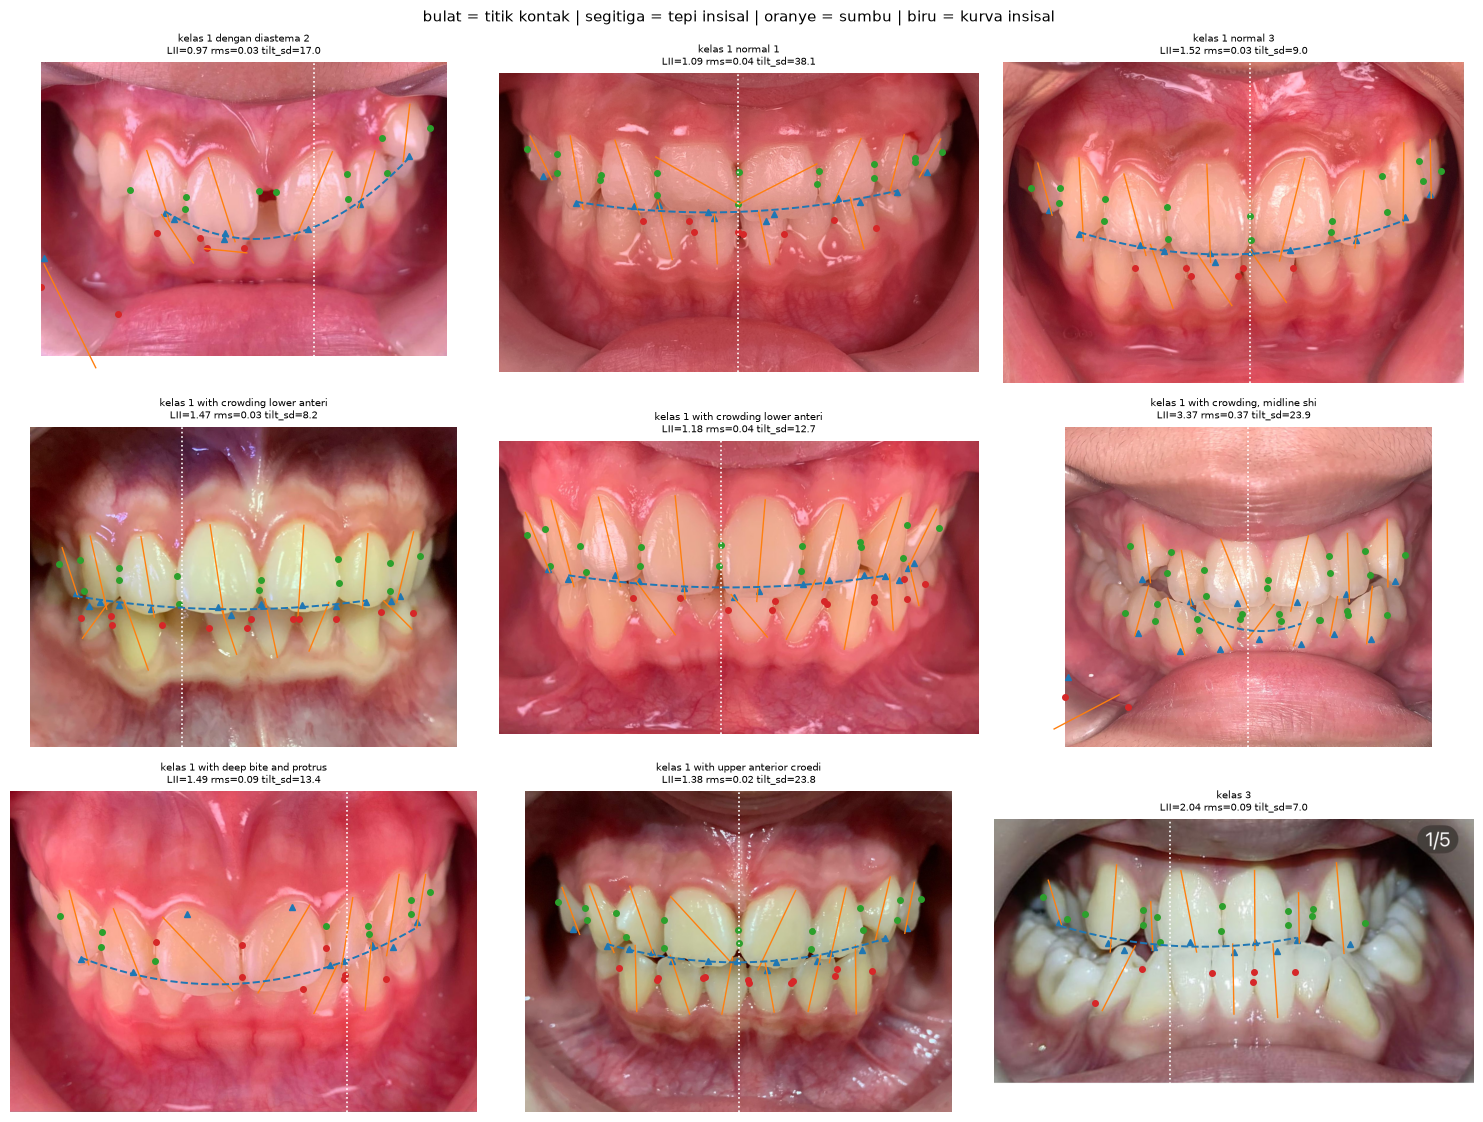

In [39]:
def show_landmarks(n, ax=None):
    d, lm = SEG[n], LM[n]
    if ax is None: _, ax = plt.subplots(figsize=(7,5))
    ax.imshow(d["rgb"]); ax.axis("off")
    up = [t for t in UPPER_ANT if t in lm]
    for t in sorted(lm):
        L = lm[t]; up_ = t//10 in (1,2)
        col = "#2ca02c" if up_ else "#d62728"
        ax.plot(*L["contact_L"], "o", ms=4, color=col)
        ax.plot(*L["contact_R"], "o", ms=4, color=col)
        ax.plot(*L["incisal"], "^", ms=5, color="#1f77b4")
        a = np.radians(L["tilt"]); dx, dy = np.sin(a)*L["h"]/2, np.cos(a)*L["h"]/2
        ax.plot([L["cx"]-dx, L["cx"]+dx], [L["cy"]-dy, L["cy"]+dy], "-", lw=1, color="#ff7f0e")
    if len(up) >= 4:
        order = sorted(up, key=lambda t: lm[t]["cx"])
        P = np.array([lm[t]["incisal"] for t in order])
        xs = np.linspace(P[:,0].min(), P[:,0].max(), 60)
        xn = (xs - P[:,0].mean())/(np.ptp(P[:,0])+1e-8)
        cf = np.polyfit((P[:,0]-P[:,0].mean())/(np.ptp(P[:,0])+1e-8), P[:,1], 2)
        ax.plot(xs, np.polyval(cf, xn), "--", lw=1.4, color="#1f77b4")
        ax.axvline(np.median([lm[t]["cx"] for t in up]), ls=":", lw=1.2, color="w")
    m = MET.loc[n]
    ttl = (f"{n[:34]}\nLII={m.get('LII_norm', np.nan):.2f} "
           f"rms={m.get('incisal_rms', np.nan):.2f} tilt_sd={m.get('tilt_std', np.nan):.1f}")
    ax.set_title(ttl, fontsize=7)

good = [n for n in LM if MET.loc[n].get("valid", False)]
ncol = 3; nrow = int(np.ceil(len(good)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.8*nrow))
for a in np.ravel(axes): a.axis("off")
for k, n in enumerate(good): show_landmarks(n, np.ravel(axes)[k])
plt.suptitle("bulat = titik kontak | segitiga = tepi insisal | oranye = sumbu | biru = kurva insisal",
             fontsize=11)
plt.tight_layout(); plt.show()

## 8. Uji akal sehat: apakah metriknya bergerak ke arah yang benar?

Dua pemeriksaan sebelum metrik ini dipercaya.

**(a) Kontrol sintetis.** Dibuat dua lengkung buatan — satu rapi sempurna, satu diacak — lalu
metrik dihitung pada keduanya. Kalau lengkung berjejal tidak menghasilkan `LII_norm` dan
`incisal_rms` yang lebih tinggi, ada bug di kodenya, bukan di datanya. Ini menguji **implementasi**,
terpisah dari pertanyaan apakah metriknya bermakna secara klinis.

**(b) Weak-label.** Kelompok `crowding` seharusnya `LII_norm`-nya di atas kelompok `normal`.
n sangat kecil, jadi ini indikasi arah — bukan bukti.

In [40]:
def synth_arch(jitter=0.0, seed=0):
    """Lengkung sintetis 6 gigi; jitter=0 -> rapi sempurna."""
    rng = np.random.default_rng(seed)
    H, W = 400, 700
    lm = {}
    widths = {13:52, 12:44, 11:62, 21:62, 22:44, 23:52}
    order  = [13,12,11,21,22,23]
    x = 140.0
    for t in order:
        w = widths[t]; h = 130
        dx = rng.normal(0, jitter*w);  dy = rng.normal(0, jitter*h)
        ti = rng.normal(0, jitter*25)
        cx, cy = x + w/2 + dx, 200 + dy
        lm[t] = {"cx": cx, "cy": cy, "w": w, "h": h, "tilt": float(ti),
                 "contact_L": np.array([cx-w/2, cy+h*0.3]),
                 "contact_R": np.array([cx+w/2, cy+h*0.3]),
                 "incisal":   np.array([cx, cy+h/2]),
                 "area": w*h, "solidity": 0.95, "y0": cy-h/2, "y1": cy+h/2}
        x += w
    return lm

for jit, lab in [(0.0, "rapi sempurna"), (0.12, "sedang"), (0.28, "sangat berjejal")]:
    m = metrics(synth_arch(jit, seed=3))
    print(f"  {lab:18s} LII_norm={m['LII_norm']:6.3f}  incisal_rms={m['incisal_rms']:6.3f}  "
          f"tilt_std={m['tilt_std']:5.2f}")
print("\n-> ketiganya harus MENAIK dari atas ke bawah. Kalau tidak, ada bug.")

  rapi sempurna      LII_norm= 0.000  incisal_rms= 0.000  tilt_std= 0.00
  sedang             LII_norm= 1.214  incisal_rms= 0.150  tilt_std= 1.44
  sangat berjejal    LII_norm= 2.295  incisal_rms= 0.425  tilt_std= 3.35

-> ketiganya harus MENAIK dari atas ke bawah. Kalau tidak, ada bug.


In [ ]:
ALIAS = {"normal":["normal"], "diastema":["diastema"],
         "crowding":["crowding","croeding"], "crossbite":["crossbite"],
         "protrusion":["protrusion"], "open bite":["open bite"], "deep bite":["deep bite"]}
def labels_of(n):
    ln = n.lower()
    return [k for k,a in ALIAS.items() if any(x in ln for x in a)] or ["lain"]

rows = []
for n in good:
    for lab in labels_of(n):
        rows.append({"label": lab, **{c: MET.loc[n].get(c) for c in
                     ["LII_norm","incisal_rms","tilt_std","width_asym","midline_dev","overbite_proxy"]}})
WL = pd.DataFrame(rows)
print(WL.groupby("label").agg(["mean","count"]).round(3).to_string())
WL.to_csv(os.path.join(CFG["out_dir"], "weak_label_metrics.csv"), index=False)

## 9. Ekspor

`seg_out/metrics_geometry.csv` adalah keluaran utama: satu baris per foto, kolomnya metrik
kerapihan tanpa satuan. Inilah matriks fitur yang nanti diregresikan ke skor laten Bradley-Terry
dari studi perbandingan berpasangan.

Mask juga disimpan supaya tidak perlu menjalankan SAM 2 ulang, dan bisa langsung dijadikan data
latih YOLOv8-seg kalau nanti mau otomatis penuh.

In [41]:
np.savez_compressed(
    os.path.join(CFG["out_dir"], "masks.npz"),
    **{f"{n}__{i}": SEG[n]["keep"][i][0] for n in SEG for i in range(len(SEG[n]["keep"]))})
with open(os.path.join(CFG["out_dir"], "fdi.json"), "w") as f:
    json.dump({n: {str(k): int(v) for k, v in SEG[n]["fdi"].items()} for n in SEG}, f, indent=1)

summary = {
    "backend": BACKEND, "n_foto": len(SEG),
    "n_valid": int(MET["valid"].sum()) if "valid" in MET else 0,
    "median_gigi_atas": float(np.nanmedian(MET["n_upper"].astype(float))) if "n_upper" in MET else None,
    "metrik": [c for c in MET.columns if c not in ("valid","n_upper","n_lower","w_ref_px")],
}
with open(os.path.join(CFG["out_dir"], "summary3.json"), "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nFile:", sorted(os.listdir(CFG["out_dir"])))

{
  "backend": "sam2",
  "n_foto": 18,
  "n_valid": 9,
  "median_gigi_atas": 3.5,
  "metrik": [
    "fdi_suspect",
    "LII_norm",
    "LII_max",
    "LII_euclid",
    "incisal_rms",
    "tilt_std",
    "tilt_asym",
    "width_asym",
    "solidity_min",
    "midline_dev",
    "cant_deg",
    "wh_central",
    "overbite_proxy"
  ]
}

File: ['fdi.json', 'fdi_map.npy', 'masks.npz', 'metrics_geometry.csv', 'summary3.json', 'weak_label_metrics.csv']


## 10. Diagnostik filter — kenapa sebuah foto gagal

Pada run pertama, **9 dari 18 foto tidak valid** dan median gigi atas cuma 3.5 dari 6. Delapan foto
bahkan hanya mendapat 0–2 gigi atas.

Sebelum menyetel apa pun, satu pertanyaan harus dijawab dulu:

> **Apakah SAM memang tidak menemukan giginya, atau SAM menemukannya tapi filter kita yang
> membuangnya?**

Keduanya butuh penanganan yang sama sekali berbeda. Kalau filter yang salah → cukup setel ambang
di CFG. Kalau SAM yang gagal → tidak ada ambang yang bisa menolong, dan kita harus pindah ke mode
klik-per-gigi (`SAM2ImagePredictor` dengan prompt titik).

Sel di bawah menjawabnya: ia menjalankan SAM tanpa filter, lalu melaporkan **kriteria mana yang
menolak setiap mask**.

In [42]:
FAIL_PHOTO = None     # None = pilih otomatis foto dgn gigi atas paling sedikit

_cnt = {n: sum(1 for v in SEG[n]["fdi"].values() if v//10 in (1,2)) for n in SEG}
if FAIL_PHOTO is None:
    FAIL_PHOTO = min(_cnt, key=_cnt.get)
print("Foto yang didiagnosis:", FAIL_PHOTO, f"(gigi atas terdeteksi: {_cnt[FAIL_PHOTO]})")

_p = paths[names.index(FAIL_PHOTO)]
_rgb = load_rgb(_p)
_raw = generate_masks(_rgb)
print(f"SAM menghasilkan {len(_raw)} mask MENTAH (sebelum filter apa pun)\n")

_r01 = _rgb.astype(np.float32)/255.
_s, _v = rgb_to_sv(_r01)

rows = []
for i, m in enumerate(_raw):
    st = mask_stats(m, _r01, _s, _v)
    if st is None:
        rows.append({"idx": i, "tolak": "terlalu kecil (<20 px)"}); continue
    why = []
    if st["frac"] < CFG["area_min_frac"]:  why.append(f"luas<{CFG['area_min_frac']}")
    if st["frac"] > CFG["area_max_frac"]:  why.append(f"luas>{CFG['area_max_frac']}")
    if st["sat"]  > CFG["sat_max"]:        why.append(f"saturasi>{CFG['sat_max']}")
    if st["val"]  < CFG["val_min"]:        why.append(f"terang<{CFG['val_min']}")
    if not (CFG["aspect_min"] <= st["aspect"] <= CFG["aspect_max"]): why.append("aspek")
    if st["solidity"] < CFG["solidity_min"]: why.append(f"soliditas<{CFG['solidity_min']}")
    rows.append({"idx": i, "frac": round(st["frac"],4), "aspect": round(st["aspect"],2),
                 "sat": round(st["sat"],2), "val": round(st["val"],2),
                 "sol": round(st["solidity"],2),
                 "tolak": ", ".join(why) if why else "LOLOS"})

D = pd.DataFrame(rows)
lolos = D[D["tolak"] == "LOLOS"]
print(f"Lolos filter: {len(lolos)} dari {len(_raw)} mask\n")
print(D.sort_values("frac", ascending=False, na_position="last").head(25).to_string(index=False))

print("\n--- kriteria penolak paling sering ---")
from collections import Counter
cnt = Counter(w for r in rows if r["tolak"] not in ("LOLOS",)
              for w in str(r["tolak"]).split(", "))
for k, c in cnt.most_common():
    print(f"  {c:3d}x  {k}")

Foto yang didiagnosis: kelas 1 with deep bite and protrusion 2 (gigi atas terdeteksi: 0)
SAM menghasilkan 6 mask MENTAH (sebelum filter apa pun)

Lolos filter: 0 dari 6 mask

 idx   frac  aspect  sat  val  sol                     tolak
   0 0.0457    1.14 0.49 0.94 1.00             saturasi>0.45
   1 0.0413    1.09 0.49 0.92 0.99             saturasi>0.45
   3 0.0227    1.49 0.54 0.94 0.99             saturasi>0.45
   2 0.0206    1.42 0.56 0.93 0.99             saturasi>0.45
   5 0.0027    0.86 0.69 0.48 1.01 luas<0.004, saturasi>0.45
   4 0.0012    0.64 0.60 0.70 1.05 luas<0.004, saturasi>0.45

--- kriteria penolak paling sering ---
    6x  saturasi>0.45
    2x  luas<0.004


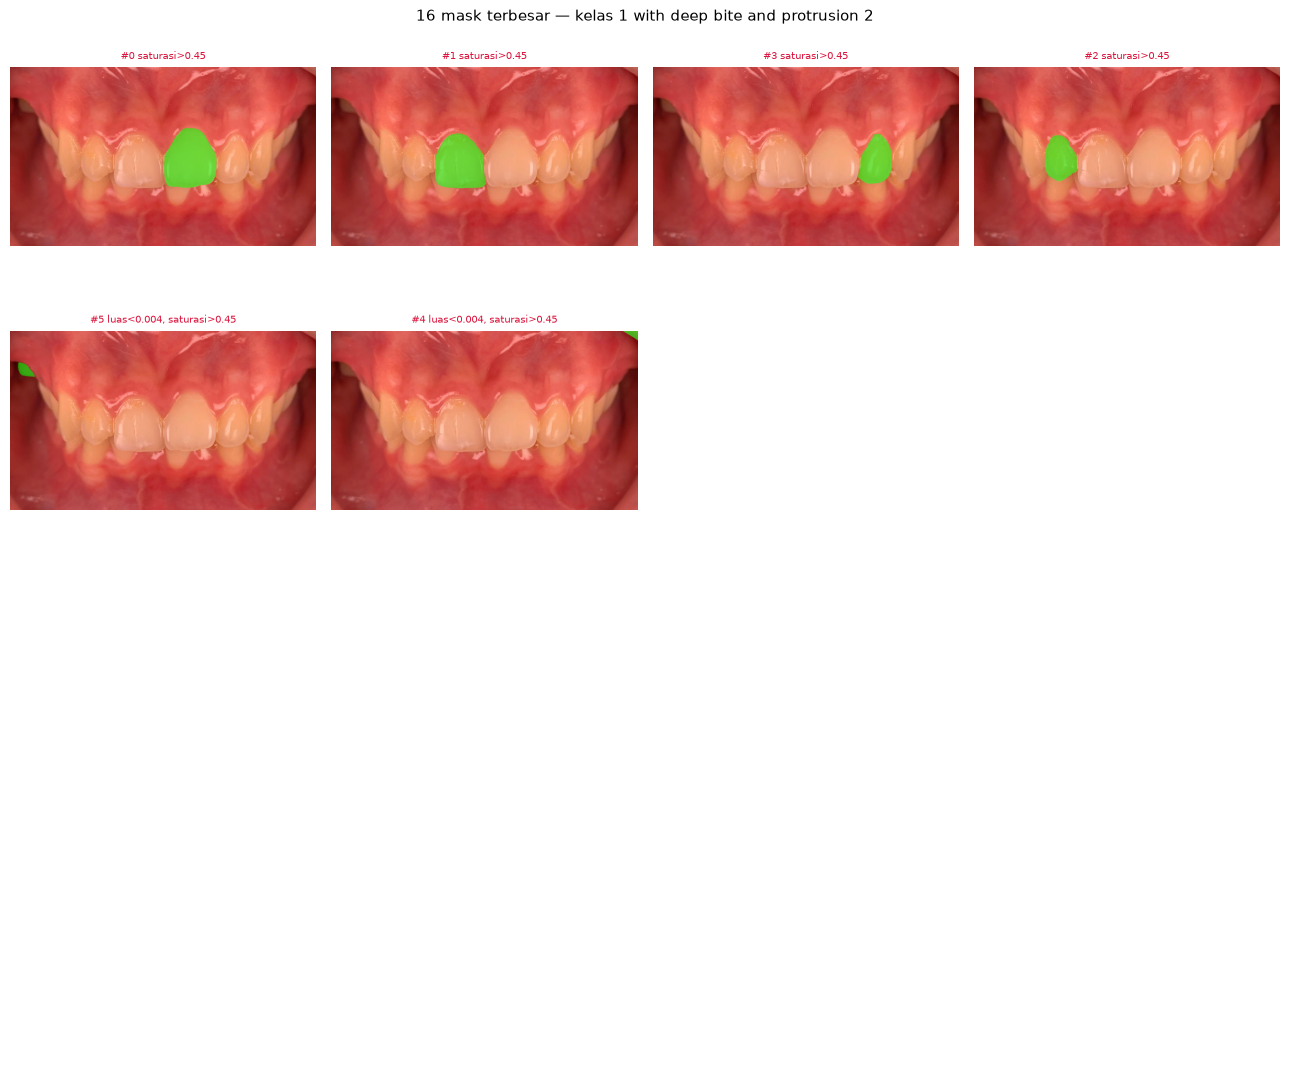

CARA MEMBACA:
 • Ada mask yang jelas satu gigi tapi tertolak  -> masalah FILTER, setel ambang di CFG.
 • Gigi tergabung jadi satu blok / tidak ada mask per gigi -> masalah SAM,
   ambang tidak akan menolong. Pindah ke mode klik-per-gigi (SAM2ImagePredictor).


In [43]:
# Lihat 16 mask terbesar apa adanya: apakah ada yang jelas-jelas gigi tapi tertolak?
big = sorted(range(len(_raw)), key=lambda i: -_raw[i].sum())[:16]
fig, axes = plt.subplots(4, 4, figsize=(13, 11))
for ax, i in zip(np.ravel(axes), big):
    ov = _rgb.copy()
    ov[_raw[i]] = (0.45*ov[_raw[i]] + 0.55*np.array([0,255,0])).astype(np.uint8)
    ax.imshow(ov); ax.axis("off")
    r = D[D["idx"] == i].iloc[0]
    ok = r["tolak"] == "LOLOS"
    ax.set_title(f"#{i} {r['tolak'][:34]}", fontsize=7, color=("green" if ok else "crimson"))
for ax in np.ravel(axes)[len(big):]: ax.axis("off")
plt.suptitle(f"16 mask terbesar — {FAIL_PHOTO[:44]}", fontsize=11)
plt.tight_layout(); plt.show()

print("CARA MEMBACA:")
print(" • Ada mask yang jelas satu gigi tapi tertolak  -> masalah FILTER, setel ambang di CFG.")
print(" • Gigi tergabung jadi satu blok / tidak ada mask per gigi -> masalah SAM,")
print("   ambang tidak akan menolong. Pindah ke mode klik-per-gigi (SAM2ImagePredictor).")

In [44]:
# Sapuan ambang: berapa gigi yang lolos kalau satu kriteria dilonggarkan?
import copy
_base = copy.deepcopy(CFG)
def n_pass(**kw):
    for k, v in kw.items(): CFG[k] = v
    n = len(filter_teeth(_raw, _rgb))
    CFG.update(_base); return n

print(f"baseline: {n_pass()} mask lolos\n")
for key, vals in [("sat_max",[0.45,0.55,0.65,0.75]),
                  ("val_min",[0.42,0.35,0.28,0.20]),
                  ("solidity_min",[0.78,0.70,0.60,0.50]),
                  ("aspect_max",[4.2,5.0,6.0]),
                  ("area_min_frac",[0.004,0.002,0.001])]:
    print(f"  {key:15s}", "  ".join(f"{v}->{n_pass(**{key:v})}" for v in vals))
print("\nKalau melonggarkan satu ambang saja sudah menaikkan jumlah lolos ke ~6 gigi atas,")
print("masalahnya filter. Kalau semua sapuan mentok di angka rendah, masalahnya SAM.")

baseline: 0 mask lolos

  sat_max         0.45->0  0.55->3  0.65->4  0.75->4
  val_min         0.42->0  0.35->0  0.28->0  0.2->0
  solidity_min    0.78->0  0.7->0  0.6->0  0.5->0
  aspect_max      4.2->0  5.0->0  6.0->0
  area_min_frac   0.004->0  0.002->0  0.001->0

Kalau melonggarkan satu ambang saja sudah menaikkan jumlah lolos ke ~6 gigi atas,
masalahnya filter. Kalau semua sapuan mentok di angka rendah, masalahnya SAM.


## Langkah berikutnya

Metrik di sini **belum punya variabel target**. Ia mendeskripsikan geometri, tapi belum tahu
geometri mana yang dinilai rapi oleh manusia. Itu butuh studi perbandingan berpasangan
(28 gambar: 18 pasien + 10 anchor AC) → Bradley-Terry → skor laten, lalu regresi ridge dari
metrik-metrik ini ke skor tersebut, dievaluasi leave-one-out.

Saat itulah koefisiennya jadi bisa dibaca: *"LII menyumbang sekian, midline sekian"* — kalimat
yang bisa didiskusikan dengan drg. Laura dan dipertahankan di sidang.